# Example with Pullally dataset

In [2]:
# libraries
import rospy
import rosbag
from nav_msgs.msg import Path
from nav_msgs.msg import Odometry
from geometry_msgs.msg import PoseStamped
from sensor_msgs.msg import LaserScan

import sensor_msgs.point_cloud2 as pc2 
import math

import numpy as np
import matplotlib.pyplot as plt
import csv
from scipy.linalg import expm

from hausdorff.njit_hausdorff import MHD_sensor
from hausdorff.njit_voronoi import find_voronoi_img

from utils.pix2meters_v4 import find_pose
from utils.init_data import init_sigmas, init_data_p0, init_memories
from utils.match_common import map_initial_estimate_v0, upload_map
from utils.match_common import join_scan_data_plus4

from EKF.model import model_particle
from EKF.step_model import step_model
from EKF.jacobianos import jacobianos_particle

from utils.param_pullally import S_MAX_RANGE
from utils.param_pullally import XMAX_pix, YMAX_pix
from utils.param_pullally import THETA_MX, THETA_MN, D_MN 

## read point cloud

In [3]:
#bag_path -->> write YOUR_DATASET_FOLDER
bag_path = '/media/paola/PAO_HD330/Dataset_Pullaly/DS_2_Pullally_20230806/DS_P1_20230806/D1T1_20230806_1030/2023-08-06-10-50-33_1.bag' 
topic = '/velodyne_points'
topic_gnss = '/vo'
u_path = 'u_&_time.npz'
limits = [0.0 , 0.4, 0.8, 1.2, 1.6]
STEP_SCAN_VELODYNE = (2*np.pi)/898

In [4]:
def pointcloud_to_2d_scan(
    msg,
    limit_0=0.0,
    limit_1=0.2,
    angle_min=-math.pi,
    angle_max=math.pi,
    angle_increment= STEP_SCAN_VELODYNE,
):
    """
    Convert a PointCloud2 into a simulated 2D LaserScan.
    Points are selected by Z-range: limit_0 < z < limit_1.
    """

    # ---- 1. Extract XYZ points from the PointCloud2 ----
    pts = np.array(list(pc2.read_points(msg, field_names=("x", "y", "z"), skip_nans=True)))

    if pts.size == 0:
        return msg.header.stamp, None

    # ---- 2. Select only the height slice ----
    z = pts[:, 2]
    mask = (z >= limit_0) & (z <= limit_1)
    pts = pts[mask]

    if pts.size == 0:
        return msg.header.stamp, None

    # ---- 3. Compute angle and distance for each point ----
    xs, ys = pts[:, 0], pts[:, 1]
    angles = np.arctan2(ys, xs)
    ranges = np.hypot(xs, ys)   # <-- FIXED
    #data = angles, ranges
    #print(len(angles), len(ranges))

    # ---- 4. Prepare laser scan bins ----
    num_bins = int(np.ceil((angle_max - angle_min) / angle_increment))
    #print("num_bins : " +str(num_bins))
    scan = np.full(num_bins, np.inf)   # <-- standard behavior

    # ---- 5. Convert angles → indices ----
    idxs = ((angles - angle_min) / angle_increment).astype(int)
    #print("idxs : " +str(idxs))

    # ---- 6. Keep only valid indices ----
    valid = (idxs >= 0) & (idxs < num_bins)
    idxs = idxs[valid]
    ranges = ranges[valid]
    #np.minimum.at(scan, idxs, ranges)

    # ---- 7. Assign minimum distance per bin ----
    for i, d in zip(idxs, ranges):
        if d < scan[i]:
            scan[i] = d

    return scan#, data

In [5]:
bag = rosbag.Bag(bag_path)
scan_0 = []
scan_1 = []
scan_2 = []
scan_3 = []
time_scans = []
limits = [0.0 , 0.4, 0.8, 1.2, 1.6 ]
for topic, msg, t in bag.read_messages(topics= [topic]):
    scan0 =pointcloud_to_2d_scan(msg, limit_0 = limits[0], limit_1 = limits[1])
    scan1 =pointcloud_to_2d_scan(msg, limit_0 = limits[1], limit_1 = limits[2])
    scan2 =pointcloud_to_2d_scan(msg, limit_0 = limits[2], limit_1 = limits[3])
    scan3 =pointcloud_to_2d_scan(msg, limit_0 = limits[3], limit_1 = limits[4])
    ring_time = ([msg.header.stamp.secs, msg.header.stamp.nsecs])
    scan_0.append(scan0)
    scan_1.append(scan1)
    scan_2.append(scan2)
    scan_3.append(scan3)
    time_scans.append(ring_time)
bag.close()

## read 'u' commands and ind matches

In [33]:
u_data_load= np.load(u_path)
u_data = u_data_load['u']
u_time = u_data_load['time_u']

In [12]:
def find_matched_times (times0, time2match):
    numbers = []
    timenew = []
    for i in range(len(times0)):
        x = np.absolute(time2match - times0[i])
        numbers.append(x.argmin())
        #print(numbers[-1])
        timenew.append(time2match[numbers[-1]])
        #if np.min(x)>1:
        #    print(i,np.min(x),timenewgnss[-1], x.argmin()) 
    return np.array(numbers), np.array(timenew)


def find_elements(iarray, arrayelements):
    newarray = []
    for i in iarray:
        newarray.append(arrayelements[i])
    return np.array(newarray)

In [16]:
time_scn = []
aux = 0
for data1 in time_scans:
    t1 = data1[0] + (data1[1])*10**-9
    if aux == 0:
        time_scn.append(t1)
        aux = -1
    else:
        time_scn.append(t1) 
    
time_scan = np.array(time_scn)
scan_0 = np.array(scan_0)
scan_1 = np.array(scan_1)
scan_2 = np.array(scan_2)
scan_3 = np.array(scan_3)

In [27]:
numbers_, new_t = find_matched_times(u_time, time_scan)

for i in range(len(new_t)):
    if i ==0:
        ts = []
    else:
        ts.append(new_t[i]- new_t[i-1])
ts_array = np.array(ts)

In [17]:
n_scan0 = find_elements(numbers_, scan_0)
n_scan1 = find_elements(numbers_, scan_1)
n_scan2 = find_elements(numbers_, scan_2)
n_scan3 = find_elements(numbers_, scan_3)

## Matching with Hausdorff

In [19]:
# init variables 
sigma_P, P_k0, Q_k, R_k = init_sigmas()
x_k0_m = np.array([0.0, 0.0, 0.0]) # measured value [x, y, theta]
x, x_k_k, x_k1_k, z_k, P_k_k = init_data_p0 (x_k0_m, P_k0)
lista_hausdorff_prom, lista_errores, lista_sumll, es_lost, std_list = init_memories ()
x = x_k0_m.reshape((1, len(x_k0_m)))        # real
m_prob_occ, m_log_odds = map_initial_estimate_v0(XMAX_pix, YMAX_pix)
#print(new_t.shape, ts_array.shape, u_data.shape,n_scan0.shape)

In [39]:
init_val, val = 0 , 235
for k in range(init_val, val):
    lidar_data, mapa_data = join_scan_data_plus4(n_scan0[k], n_scan1[k], n_scan2[k], n_scan3[k], THETA_MX, THETA_MN, S_MAX_RANGE, D_MN)

    if k == 0:  
        m_prob_occ, m_log_odds, sum_ll = upload_map(lidar_data, x[k,:], m_prob_occ, m_log_odds)
        m_prob_occ, m_log_odds, sum_ll = upload_map(mapa_data, x[k,:], m_prob_occ, m_log_odds)
        print("creo mapa")

    else:
        u = u_data[k-1]#[0.002 , 0.002]#u_const_array[k-1]
        time_ini = new_t[k-1]
        Ts = ts_array[k-1]
        _, x_aux = step_model(model_particle, u, time_ini, sigma_P, Ts, x[k-1,:])
        x = np.vstack((x,(x_aux.T)[-1]))

        A, B, G, C, D, H = jacobianos_particle(x_k_k[k-1,:], u )
        Ad = expm(A*Ts) # Ojo usar "expm" no "exp"!!!
        Bd = ((Ad*Ts).dot(np.eye(len(Ad))-A*Ts/2.)).dot(B) # Bd = Ad*Ts*(eye(size(Ad))-A*Ts/2)*B;
        Gd = ((Ad*Ts).dot(np.eye(len(Ad))-A*Ts/2.)).dot(G) # Gd = Ad*Ts*(eye(size(Ad))-A*Ts/2)*G;
        A, B, G = Ad, Bd, Gd

        # -- Predicción por integración del modelo no-lineal
        _, x_aux = step_model(model_particle, u, time_ini, sigma_P, Ts, x_k_k[k-1,:])
        x_k1_k = np.vstack((x_k1_k,(x_aux.T)[-1]))                             # Store x_{k+1|k}
        z_k1_k_aux = C.dot(x_k1_k[k,:]) + D.dot(u)                   # <-- z_{k+1|k}

        P_k1_k_aux = (A.dot(P_k_k[k-1,:,:])).dot(A.T) + (G.dot(Q_k)).dot(G.T) # <-- P_{k+1|k}
        S_k1_k_aux = (C.dot(P_k1_k_aux)).dot(C.T) + (H.dot(R_k)).dot(H.T)   # <-- S_{k+1|k}

        v_distances, pose_0 = find_voronoi_img (m_prob_occ), find_pose(x_k1_k[k,:])
        z_k1_aux, lista_hausdorff_prom = MHD_sensor(k,lidar_data, v_distances, pose_0, lista_hausdorff_prom)
                        
        e = z_k1_aux - z_k1_k_aux
        distace_e = math.sqrt(e[0]**2 + e[1]**2)

        K = (P_k1_k_aux.dot(C.T)).dot(np.linalg.inv(S_k1_k_aux))# <-- K_{k+1}

        lista_errores.append([e[0], e[1], e[2], distace_e])

        x_k_k_aux = x_k1_k[k,:] + K.dot(e) 
        P_k_k_aux = P_k1_k_aux - (K.dot(S_k1_k_aux)).dot(K.T)   # <-- P_{k+1|k+1}
        z_k = np.vstack((z_k, z_k1_aux))                         # Store z_{k+1}
        x_k_k = np.vstack((x_k_k, x_k_k_aux))                    # Store x_{k+1|k+1}
        P_k_k = np.vstack((P_k_k, P_k_k_aux[np.newaxis,...]))    # Store P_{k+1|k+1}

        m_prob_occ, m_log_odds, sum_ll = upload_map(lidar_data, x_k_k_aux, m_prob_occ, m_log_odds)
        m_prob_occ, m_log_odds, sum_ll = upload_map(mapa_data, x_k_k_aux, m_prob_occ, m_log_odds)
        

/home/paola/.local/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:39: UserWarning: The following arguments have no effect for a chosen solver: `teval`.
  warn("The following arguments have no effect for a chosen solver: {}."


i : 21dataP : [-1, 1, 2, 0]
i : 22dataP : [1, 0, 1, 0]
i : 23dataP : [1, 0, 2, 0]
i : 24dataP : [1, -1, 1, 0]
i : 25dataP : [0, 1, 1, 0]
i : 26dataP : [1, 0, 1, 0]
i : 27dataP : [0, 0, 1, 0]
i : 28dataP : [-1, 1, 1, 0]
i : 29dataP : [0, 0, 1, 0]
i : 30dataP : [0, 0, 8, 0]
i : 31dataP : [-1, 0, 1, 0]
i : 32dataP : [0, 0, 8, 0]
i : 33dataP : [0, 0, 1, 0]
i : 34dataP : [1, 1, 1, 0]
i : 35dataP : [0, 0, 8, 0]
i : 36dataP : [1, 0, 1, 0]
i : 37dataP : [1, 1, 1, 0]
i : 38dataP : [0, 0, 8, 0]
i : 39dataP : [0, 0, 8, 0]
i : 40dataP : [0, 0, 8, 0]
i : 41dataP : [1, -1, 2, 0]
i : 42dataP : [-1, 0, 2, 0]
i : 43dataP : [1, 0, 4, 0]
i : 44dataP : [1, -1, 2, 0]
i : 45dataP : [1, -1, 2, 0]
i : 46dataP : [0, 0, 8, 0]
i : 47dataP : [0, 0, 8, 0]
i : 48dataP : [-1, 1, 2, 0]
i : 49dataP : [-1, 0, 1, 0]
i : 50dataP : [0, 0, 2, 0]
i : 51dataP : [-1, 1, 1, 0]
i : 52dataP : [0, 1, 1, 0]
i : 53dataP : [1, 0, 1, 3]
i : 54dataP : [0, -1, 1, 0]
i : 55dataP : [0, 0, 8, 0]
i : 56dataP : [1, 0, 1, 0]
i : 57dataP : [0

## Results : Map and figures

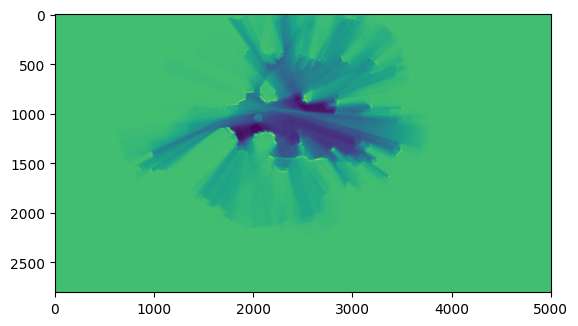

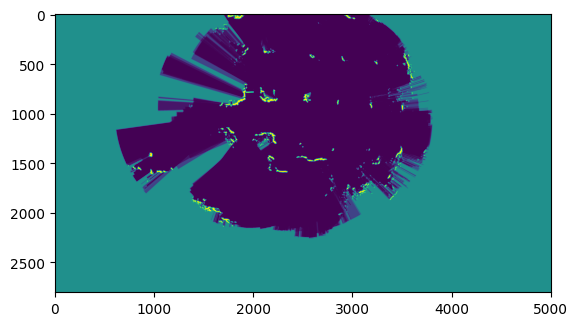

In [40]:
plt.imshow(m_log_odds)#,interpolation='nearest')#, extent = [0, XMAX, 0, YMAX])
plt.show()
plt.imshow(m_prob_occ)#,interpolation='nearest')#, extent = [0, XMAX, 0, YMAX])
plt.show()

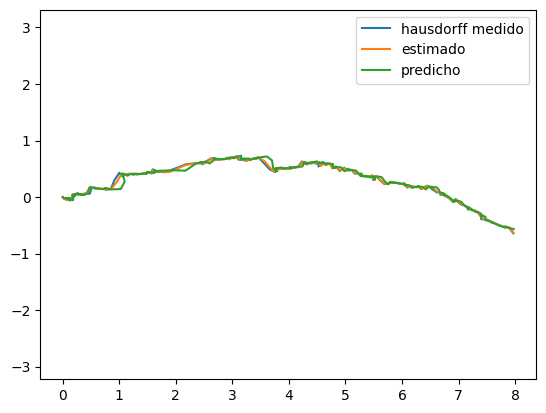

In [42]:
q = -1
#plt.plot(data_C1t1["gnss_rotated_c"][:q,0], data_C1t1["gnss_rotated_c"][:q,1], label= 'x vs y data gnss rotated')
plt.plot(z_k[:q,:1], z_k[:q,1:2], label= 'hausdorff medido')
plt.plot(x_k_k[:q,:1], x_k_k[:q,1:2], label= 'estimado')
plt.plot(x_k1_k[:q,:1], x_k1_k[:q,1:2], label= 'predicho')
#plt.plot(x[:q,:1], x[:q,1:2], label= 'real')
plt.legend(loc='upper right')
plt.axis('equal')
plt.show()

## Poses to rosbag

In [46]:
def pose_to_bag(path, out_bag = "poses.bag", topic ="/pose", frame_id = "map", 
                child_frame_id = "base_link", z0 = 0.0, t = new_t , M = x_k_k):
    
    t =  t.astype(float)

    x, y, theta = M[:,0].astype(float), M[:,1].astype(float), M[:,2].astype(float)

    n = min(len(t), len(x), len(y), len(theta))
    t, x, y, theta = t[:n], x[:n], y[:n], theta[:n]

    z = np.full(n, z0)
    half = 0.5*theta
    #qx = np.zeros(n); qy = np.zeros(n)
    qz = np.sin(half); qw = np.cos(half)

    offset = 0.0

    with rosbag.Bag(out_bag, "w") as outbag:
        for ti, xi, yi, zi, qzi, qwi in zip(t, x, y, z, qz, qw):
            msg = Odometry()
            msg.header.stamp = rospy.Time.from_sec(offset + float(ti))
            msg.header.frame_id = frame_id
            msg.child_frame_id = child_frame_id
            msg.pose.pose.position.x = float(xi)
            msg.pose.pose.position.y = float(yi)
            msg.pose.pose.position.z = float(zi)
            msg.pose.pose.orientation.x = 0.0
            msg.pose.pose.orientation.y = 0.0
            msg.pose.pose.orientation.z = float(qzi)
            msg.pose.pose.orientation.w = float(qwi)
            outbag.write(topic, msg, msg.header.stamp)
    print("Wrote", path + out_bag)

In [47]:
pose_to_bag(path = '/media/paola/PAO_HD330/Dataset_Pullaly/DS_2_Pullally_20230806/DS_P1_20230806/D1T1_20230806_1030/', out_bag = "poses.bag",
             topic ="/pose", frame_id = "map", child_frame_id = "base_link", z0 = 0.0, t = new_t , M = x_k_k)

Wrote /media/paola/PAO_HD330/Dataset_Pullaly/DS_2_Pullally_20230806/DS_P1_20230806/D1T1_20230806_1030/poses.bag


## Complete rosbag

In [3]:
#input_bags -- >  the last saved poses.bag, and YOUR_DATASET_FOLDER
input_bags = [
    "poses.bag",
    "/media/paola/PAO_HD330/Dataset_Pullaly/DS_2_Pullally_20230806/DS_P1_20230806/D1T1_20230806_1030/2023-08-06-10-50-33_1.bag"
]

output_bag = "data_pullally_example.bag"

with rosbag.Bag(output_bag, 'w') as outbag:
    for bag_path in input_bags:
        with rosbag.Bag(bag_path, 'r') as inbag:
            for topic, msg, t in inbag.read_messages():
                outbag.write(topic, msg, t)